In [ ]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
import pandas as pd
import itertools

In [2]:
cz_se= pd.read_csv('data/data_cz_3ncut_truc1=300_select.txt')
cz= pd.read_csv('data/data_cz_3ncut_truc1=300.txt')
# cz_abs_se= pd.read_csv('data/data_cz_3ncut_truc1=300_abs_select.txt')
# cz_abs= pd.read_csv('data/data_cz_3ncut_truc1=300_abs.txt')
# params = cz_3ncut_se.to_numpy()[[0, 5, 10, 15, 20, 25, 30],:]
# cz_old = pd.read_csv('data/data_fig/data_cz_n2_20.txt')
# pa = np.column_stack((cz_3ncut_se.to_numpy(), np.round(f_noise_9_2us, 8), np.round(f_noise_100_5us, 8), np.round(f_noise_100_50us, 8), np.round(f_ideal_70, 8)))
# df = pd.DataFrame(pa, columns=['tg', 'drive_amp', 'detune', 'f_300_200_True',
#                                'f_300_1000_True', 'f_noise_9_2us', 'f_noise_100_5us', 'f_noise_100_50us', 'f_ideal_70'])
# df.to_csv('data/data_cz_3ncut_truc1=300_select.txt', sep=',', index=False, header=True)
tg_list = [32, 74, 116, 158, 200]  # Select the first row for testing


In [4]:
print(cz['drive_amp'].mean(), cz['drive_amp'].median())
print(cz['detune'].mean(), cz['detune'].median())

0.017174696132596687 0.013895
0.019343071823204418 0.018197


### CZ Infidelity convergence on truncation (short_500_500_detune=0.023)

max_step=1e-3

In [10]:
np.arange(50, 401, 50) 


array([ 50, 100, 150, 200, 250, 300, 350, 400])

In [ ]:
f_short_500_500_deune1[:,2]

In [11]:
n_truc_list = np.arange(50, 401, 50) 
f_short_500_500_deune1 = np.array([
[-0.44036360318129886, -1.3100641466806289, -2.9694003183501323, -3.608266650884425, -3.956701262270901] ,
[-0.4257042491959237, -1.329435098100823, -2.960405744067241, -3.617804505515683, -3.9499619403541577] ,
[-0.4266640276827752, -1.32219806605268, -2.8532870206082377, -3.6021031333080042, -3.9502491916064613] ,
[-0.4097213201091437, -1.3223819587508325, -2.831108805940601, -3.54289712263122, -3.9499726186882747] ,
[-0.40767590461627967, -1.3191434541124754, -2.817988096664284, -3.532108184323284, -3.948755641708353] ,
[-0.4032815345337876, -1.3222886263510543, -2.8245581519359684, -3.527181885352678, -3.948626521288063] ,
[-0.40236257936434566, -1.3227183722567524, -2.8280901149182895, -3.525549568320215, -3.9487523814188963] ,
[-0.40187166509112715, -1.322613179335865, -2.8284455811268687, -3.5256631353781933, -3.948820249268974] ,
])

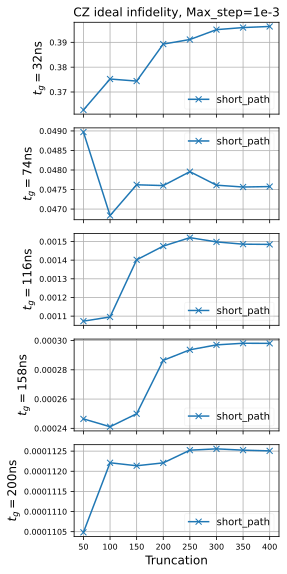

In [5]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(n_truc_list, 10**f_short_500_500_deune1[:,i], 'x-', label=fr'short_path')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=10)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

### CZ Infidelity convergence on truncation (short_1000_400)

max_step=1e-3

In [6]:
n_truc_list = [ 75, 100, 125, 150, 175, 200]
n_truc_list_long = np.arange(75, 401, 25)
f_short = np.array([
[-0.41152054788734743, -1.3095661711664661, -2.960470769994891, -3.6026816095267233, -3.962572442062969], 
[-0.399606146876086, -1.3284484534871313, -2.950264518775447, -3.609822032921169, -3.9571201256640913], 
[-0.431585781170284, -1.3275099285920255, -2.961193529028784, -3.6176349709399047, -3.949878893216806], 
[-0.42501190989341464, -1.3267155882929713, -2.960571660257597, -3.617748175797952, -3.9501512756646733], 
[-0.41819457586869957, -1.3238399580915696, -2.863614013584925, -3.559120873022104, -3.937183521726618], 
[-0.40516014199221906, -1.3231194651505827, -2.834435324317289, -3.5577324603403446, -3.9372253241632347], 
[-0.4065678014546426, -1.3231972085389205, -2.8352223770340252, -3.546008094141041, -3.9441391061939237],

[-0.40393506, -1.32217545, -2.83678423, -3.53217227, -3.94872466] ,
[-0.4101953, -1.31879167, -2.81964688, -3.53142558, -3.94879329] ,
[-0.4042536, -1.32230425, -2.824841, -3.5282737, -3.94856166] ,
[-0.40381833, -1.32232709, -2.82346449, -3.52764125, -3.94862964] ,
[-0.40364508, -1.32269418, -2.82802328, -3.52532304, -3.94874784] ,
[-0.40327911, -1.32269083, -2.82830767, -3.52511966, -3.94880356] ,
[-0.40336342, -1.32259324, -2.82864149, -3.52597175, -3.94886785] ,
[-0.40336062, -1.32259485, -2.82856831, -3.52549741, -3.94891557] ,
])
f_all = np.array([
[-0.38644814, -1.81451339, -2.00755269, -2.64681655, -3.00084123] ,
[-0.43733365, -1.31811183, -2.9610364, -3.61813966, -3.94897779] ,
[-0.42991497, -1.32768107, -2.95953791, -3.61930989, -3.94909778] ,
[-0.44424117, -1.32255672, -2.84839748, -3.61779178, -3.95013914] ,
[-0.40213422, -1.32368489, -2.82744192, -3.617749, -3.95020103] ,
[-0.41361535, -1.32291949, -2.83443614, -3.58105046, -3.9502406] ,
[-0.41118844, -1.32270399, -2.836374, -3.58022109, -3.95028868] ,

[-0.40508128, -1.32205044, -2.83409176, -3.53333988, -3.9487286] ,
[-0.41076469, -1.32097046, -2.82127538, -3.53239684, -3.94880255] ,
[-0.40378526, -1.3223243, -2.82441675, -3.527401, -3.94861131] ,
[-0.40363823, -1.32233913, -2.82351018, -3.52761724, -3.94862743] ,
[-0.40368751, -1.32267694, -2.82810289, -3.52524752, -3.9487476] ,
[-0.40331276, -1.32255502, -2.8286146, -3.52532822, -3.94879605] ,
[-0.40337145, -1.32258397, -2.82860881, -3.52611951, -3.94886747] ,
[-0.40336062, -1.32259485, -2.82856831, -3.52549741, -3.94891557] ,
])
f_lowest = np.array([
[-0.36554139, -0.47500736, -0.41158606, -0.42936589, -0.41295294,-0.4122852 , -0.40229208],
[-1.19796746, -1.33821346, -1.31985603, -1.32375727, -1.32196245,-1.32044417, -1.32157514],
[-2.65516135, -2.94662484, -2.9422268 , -2.94682095, -2.93623823,-2.82115399, -2.83456922],
[-3.32489203, -3.62211513, -3.58514059, -3.58699464, -3.56714873,-3.53632105, -3.53659151],
[-3.75810098, -3.94816936, -3.93846721, -3.93881822, -3.94919605,-3.94893679, -3.94897473]
        ])
f_ideal_1000 = np.array([
-0.40215530875591887, -1.3226609064874149, -2.8283848283603117, -3.5222117329875666 ,
-3.9493951402836407 ,
])

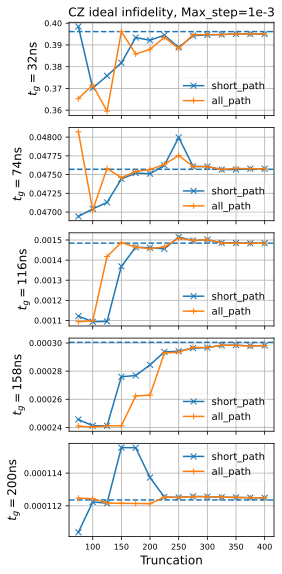

In [7]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    # ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--', label=fr'1000 states')
    ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--')
    # ax[i].plot(n_truc_list, 10**f_lowest[i, 1:], '.-', label=fr'lowest_states')
    ax[i].plot(n_truc_list_long, 10**f_short[1:,i], 'x-', label=fr'short_path')
    ax[i].plot(n_truc_list_long, 10**f_all[1:,i], '+-', label=fr'all_path')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=10)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

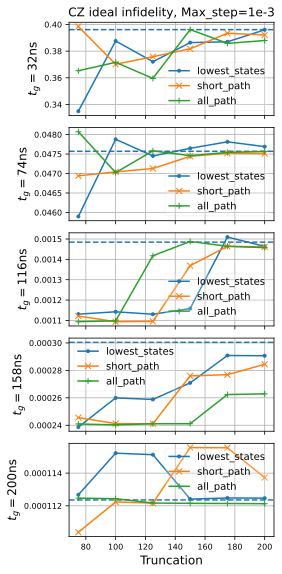

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    # ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--', label=fr'1000 states')
    ax[i].axhline(y=10**f_ideal_1000[i], linestyle='--')
    ax[i].plot(n_truc_list, 10**f_lowest[i, 1:], '.-', label=fr'lowest_states')
    ax[i].plot(n_truc_list, 10**f_short[1:,i], 'x-', label=fr'short_path')
    ax[i].plot(n_truc_list, 10**f_all[1:,i], '+-', label=fr'all_path')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=10)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

### CZ Infidelity convergence on truncation

max_step=1e-3

In [49]:
f_ideal_1000 = np.array([
-0.40215530875591887, -1.3226609064874149, -2.8283848283603117, -3.5222117329875666 ,
-3.9493951402836407 ,
])
f_ideal_500 = np.array([
-0.40190347098081924, -1.3226132149988326, -2.828124341813371, -3.524121435451491 ,
-3.9489156781770216 ,
])
f_ideal_200 = np.array([
-0.4022920793018655, -1.3215751413387333, -2.8345692209828206, -3.5365915050345276 ,
-3.9489747294329547 ,
])
f_ideal_175 = np.array([
-0.41228519521571433, -1.320444170468342, -2.8211539949966906, -3.5363210453336222 ,
-3.9489367897944523 ,
])
f_ideal_150 = np.array([
-0.41295294308784114, -1.3219624539313637, -2.9362382306487387, -3.5671487339539234 ,
-3.9491960491181155 ,
])
f_ideal_125 = np.array([
-0.429365888515395, -1.3237572669618043, -2.9468209518929065, -3.5869946398447072 ,
-3.9388182247039696 ,
])
f_ideal_100 = np.array([
-0.4115860612962274, -1.3198560293788524, -2.94222680424175, -3.5851405891926054 ,
-3.938467212637457 ,
])
f_ideal_75 = np.array([
-0.47500736108392566, -1.338213458150725, -2.946624840304518, -3.62211512653724 ,
-3.9481693559895814 ,
])
f_ideal_50 = np.array([
-0.365541388362558, -1.1979674636067066, -2.655161346452038, -3.3248920336245815 ,
-3.7581009800964025 ,
])
f_ideal_1e3 = np.column_stack((f_ideal_50, f_ideal_75, f_ideal_100, f_ideal_125, 
                               f_ideal_150, f_ideal_175, f_ideal_200, f_ideal_500, f_ideal_1000))
truc = [ 75, 100, 125, 150, 175, 200, 500, 1000]


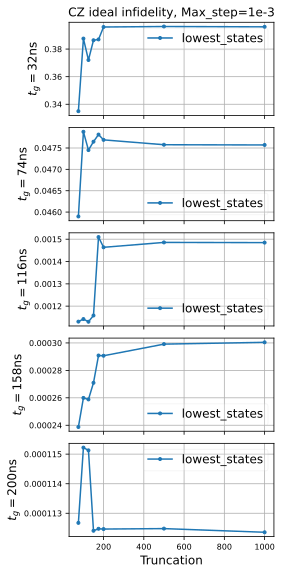

In [50]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e3[i, 1:], '.-', label=fr'lowest_states')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns', fontsize=12)
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-3', fontsize=12)
plt.tight_layout()

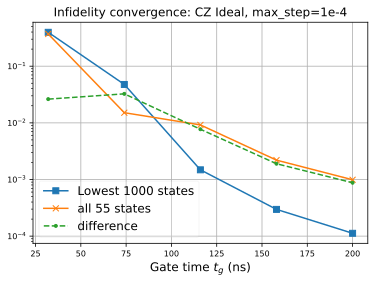

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
# ax.plot(tg_list, 10**f_ideal_200all, 'x-',  label=r'all 200 states')
# ax.plot(tg_list, np.abs(10**f_ideal_200all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_100all, 'x-',  label=r'all 100 states')
# ax.plot(tg_list, np.abs(10**f_ideal_100all - 10**f_ideal_1000), '.--',  label=r'difference')
ax.plot(tg_list, 10**f_ideal_55all, 'x-',  label=r'all 55 states')
ax.plot(tg_list, np.abs(10**f_ideal_55all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_55hand, 'x-',  label=r'hand 55 states')
# ax.plot(tg_list, np.abs(10**f_ideal_55hand - 10**f_ideal_1000), '.--',  label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### CZ Infidelity convergence on truncation

max_step=1e-4

In [ ]:
f_ideal_1000 = np.array([
-0.4021448542569617, -1.322630044450615, -2.8292207939498746, -3.5275890997936 ,
-3.949321454120114 ,
])
f_ideal_500 = np.array([
-0.4019024311954381, -1.3225689542270946, -2.8290068464858975, -3.527383190402311 ,
-3.9490553958799968 ,
])
f_ideal_200 = np.array([
-0.40231840173270494, -1.3215409903668713, -2.834576276147882, -3.536724638506567 ,
-3.948964223504374 ,
])
f_ideal_100 = np.array([
-0.4115791900644499, -1.3198497484563945, -2.942236121065928, -3.5852211042087814 ,
-3.9385615217377574 ,
])
f_ideal_55 = np.array([
-0.45025287595319985, -1.3257510272715618, -2.964305513310644, -3.619544687982036 ,
-3.9477218664684277 ,
])
f_ideal_50 = np.array([
-0.3655405764342905, -1.1979709249154762, -2.6552301504055555, -3.3251147403994836 ,
-3.7585441100976005 ,
])
f_ideal_200all = np.array([
-0.41121313361134304, -1.3226723548736532, -2.8362380292688596, -3.581491348170476 ,
-3.950496841904949 ,
])
f_ideal_100all = np.array([
-0.42990739486664165, -1.3277134086419864, -2.959479334161531, -3.6198621123898262 ,
-3.9493747206563383 ,
])
f_ideal_55all = np.array([
-0.4318735728509982, -1.8212556529595825, -2.0369030448780947, -2.6586659804851434 ,
-3.004915350805105 ,
])
f_ideal_55hand = np.array([
-0.45025287595319985, -1.3257510272715618, -2.964305513310644, -3.619544687982036 ,
-3.9477218664684277 ,
])

truc = [50, 100, 200, 500, 1000]
f_ideal_1e4 = np.column_stack((f_ideal_50, f_ideal_100, f_ideal_200, f_ideal_500, f_ideal_1000))

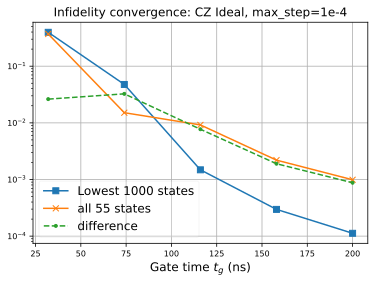

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
# ax.plot(tg_list, 10**f_ideal_200all, 'x-',  label=r'all 200 states')
# ax.plot(tg_list, np.abs(10**f_ideal_200all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_100all, 'x-',  label=r'all 100 states')
# ax.plot(tg_list, np.abs(10**f_ideal_100all - 10**f_ideal_1000), '.--',  label=r'difference')
ax.plot(tg_list, 10**f_ideal_55all, 'x-',  label=r'all 55 states')
ax.plot(tg_list, np.abs(10**f_ideal_55all - 10**f_ideal_1000), '.--',  label=r'difference')
# ax.plot(tg_list, 10**f_ideal_55hand, 'x-',  label=r'hand 55 states')
# ax.plot(tg_list, np.abs(10**f_ideal_55hand - 10**f_ideal_1000), '.--',  label=r'difference')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

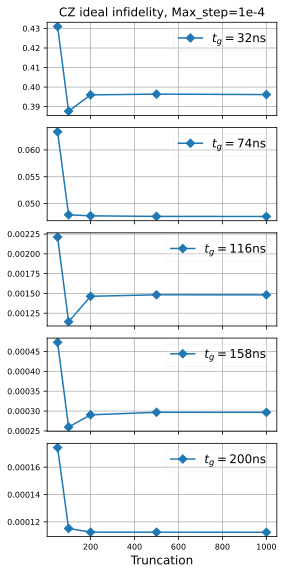

In [4]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-4', fontsize=12)
plt.tight_layout()

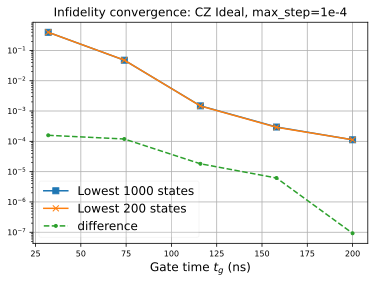

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_200, 'x-',  label=r'Lowest 200 states')
ax.plot(tg_list, np.abs(10**f_ideal_200 - 10**f_ideal_1000), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent